<h2>Modelling: Future Price Direction 2 (Logistic Regression)

Creating **baseline** logistic regression (LR) models for price direction prediction using 1, 5, 7, 14 and 20 day in-the-future direction labels.

In [1]:
# Load pre split data:
from project_paths import PRE_SPLIT_DATA_LR_PATH
import pandas as pd
print(PRE_SPLIT_DATA_LR_PATH)

data = pd.read_pickle(PRE_SPLIT_DATA_LR_PATH) #Contains Direction_1
data.head()

C:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\data\processed\direction\lr\ind_data.pkl


Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,1,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,0,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,0,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,0,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,0,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


In [2]:
X_1 = data.drop(columns=['Direction_1'])
y_1 = data['Direction_1']

In [3]:
print(X_1.shape)
X_1.head()

(4365, 13)


Price,Close,High,Low,Open,Volume,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


In [4]:
print(y_1.shape)
y_1.head()

(4365,)


33    1
34    0
35    0
36    0
37    0
Name: Direction_1, dtype: int64

In [5]:
# Check label class balance:
print(y_1.value_counts().sort_index())

Direction_1
0    2077
1    2288
Name: count, dtype: int64


~ 10% more positive labels vs negative labels.

In [6]:
# Data containing no-direction column (to systematically generate Direction_5, _7, etc, datasets)
nd_data = data.copy()
nd_data = nd_data.drop(columns=['Direction_1'])
nd_data.head()

Price,Close,High,Low,Open,Volume,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


In [7]:
from bta_direction_functions import add_direction

In [8]:
# Direction_5 (1 week)
data_5 = nd_data.copy()
data_5 = add_direction(data=data_5,shift=5)
data_5 = data_5.dropna().copy()
X_5 = data_5.drop(columns=['Direction_5'])
y_5 = data_5['Direction_5']
y_5.tail() # NaN values appear at the tail usually. Check for them
print(X_5.shape, y_5.shape)


(4360, 13) (4360,)


In [9]:
# Direction_10 (2 week)
data_10 = nd_data.copy()
data_10 = add_direction(data=data_10,shift=10)
data_10 = data_10.dropna().copy()
X_10 = data_10.drop(columns=['Direction_10'])
y_10 = data_10['Direction_10']
y_10.tail() # NaN values appear at the tail usually. Check for them
print(X_10.shape, y_10.shape)

(4355, 13) (4355,)


In [10]:
# Direction_20 (1 month)
data_20 = nd_data.copy()
data_20 = add_direction(data=data_20,shift=20)
data_20 = data_20.dropna().copy()
X_20 = data_20.drop(columns=['Direction_20'])
y_20 = data_20['Direction_20']
y_20.tail() # NaN values appear at the tail usually. Check for them
print(X_20.shape, y_20.shape)

(4345, 13) (4345,)


<h4>Train-Test Split:</h4>

In [11]:
from sklearn.model_selection import train_test_split

# Make sure to pass 'shuffle = False' to the function as we are dealing with temporal data:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.15, shuffle=False)
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y_5, test_size=0.15, shuffle=False)
X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(X_10, y_10, test_size=0.15, shuffle=False)
X_train_20, X_test_20, y_train_20, y_test_20 = train_test_split(X_20, y_20, test_size=0.15, shuffle=False)

In [12]:
print(f"X_train shape:{X_train_1.shape}")
print(f"X_test shape:{X_test_1.shape}")
print(f"y_train shape:{y_train_1.shape}")
print(f"y_test shape:{y_test_1.shape}")

X_train shape:(3710, 13)
X_test shape:(655, 13)
y_train shape:(3710,)
y_test shape:(655,)


<h4>LR Modelling:</h4>

Data processing required on the data post split:
- Scale the numerical data
- Convert to Series/Arrays. This is done by the scalers

Modelling:
- Base model
- Hypertuning

Should be a farily simple pipeline

For now the baseline model will contain all of the features (but with L1 regression). We will remove features according to the previous feature selection during the tuning process and when moving onto XGBoost.

Remember to use a different pipeline for each of the different timeframes.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

*Direction_1 (1 day)*

{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', RobustScaler())]),
                                 Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'EMA_7', 'IDR',
       'ATR_4', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist'],
      dtype='str', name='Price'))]), 'classifier': LogisticRegression(l1_ratio=1.0, max_iter=1000, penalty='l1', random_state=13,
                   solver='liblinear')}


c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.51      0.88      0.64       334
           1       0.47      0.11      0.18       321

    accuracy                           0.50       655
   macro avg       0.49      0.50      0.41       655
weighted avg       0.49      0.50      0.42       655

ROC-AUC: 0.5125


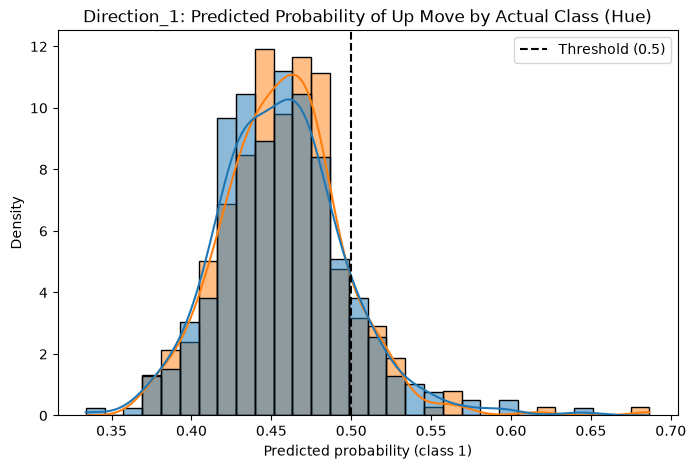

In [14]:
from sklearn.metrics import roc_auc_score

numeric_features = X_1.columns # All of the features are numeric but we will make the distinction for transparency

numeric_pipeline_1 = Pipeline([
    ("scaler", RobustScaler()) # There were outliers in violin/box plots from last NB
])

preprocessor_1 = ColumnTransformer([
    ("numeric", numeric_pipeline_1, numeric_features)
])

lr_1 = LogisticRegression(
    penalty='l1',
    C = 1.0,
    random_state=13,
    solver='liblinear', #default 'lbfgs' not L1-compatiable
    max_iter=1000,
    l1_ratio=1.0
)

pipeline_1 = Pipeline([
    ("preprocessor", preprocessor_1),
    ("classifier", lr_1)
])

print(pipeline_1.named_steps)

pipeline_1.fit(X_train_1, y_train_1)

y_pred_1 = pipeline_1.predict(X_test_1)
p_up_1 = pipeline_1.predict_proba(X_test_1)[:,1] #Probabilities

print(classification_report(y_test_1, y_pred_1))
print(f"ROC-AUC: {roc_auc_score(y_test_1, p_up_1):.4f}")

sns.histplot(x=p_up_1, hue=y_test_1.rename("Actual class"), bins=30, kde=True, stat="density", common_norm=False, ax=plt.subplots(figsize=(8, 5))[1])
plt.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
plt.title("Direction_1: Predicted Probability of Up Move by Actual Class (Hue)")
plt.xlabel("Predicted probability (class 1)")
plt.legend()
plt.show()

*Direction_5 (1 week)*

{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', RobustScaler())]),
                                 Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'EMA_7', 'IDR',
       'ATR_4', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist'],
      dtype='str', name='Price'))]), 'classifier': LogisticRegression(l1_ratio=1.0, max_iter=1000, penalty='l1', random_state=13,
                   solver='liblinear')}
              precision    recall  f1-score   support

         0.0       0.50      0.89      0.64       331
         1.0       0.46      0.10      0.16       323

    accuracy                           0.50       654
   macro avg       0.48      0.49      0.40       654
weighted avg       0.48      0.50      0.40       654

ROC-AUC: 0.5000


c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


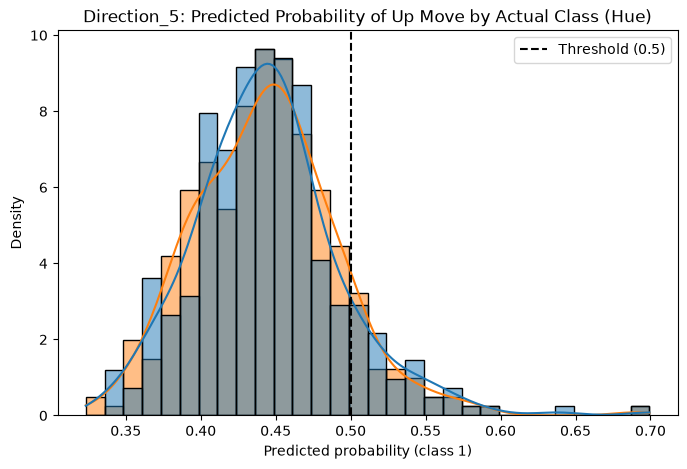

In [15]:
numeric_features = X_5.columns # All of the features are numeric but we will make the distinction for transparency

numeric_pipeline_5 = Pipeline([
    ("scaler", RobustScaler()) # There were outliers in violin/box plots from last NB
])

preprocessor_5 = ColumnTransformer([
    ("numeric", numeric_pipeline_5, numeric_features)
])

lr_5 = LogisticRegression(
    penalty='l1',
    C = 1.0,
    random_state=13,
    solver='liblinear', #default 'lbfgs' not L1-compatiable
    max_iter=1000,
    l1_ratio=1.0
)

pipeline_5 = Pipeline([
    ("preprocessor", preprocessor_5),
    ("classifier", lr_5)
])

print(pipeline_5.named_steps)

pipeline_5.fit(X_train_5, y_train_5)

y_pred_5 = pipeline_5.predict(X_test_5)
p_up_5 = pipeline_5.predict_proba(X_test_5)[:,1] #Probabilities

print(classification_report(y_test_5, y_pred_5))
print(f"ROC-AUC: {roc_auc_score(y_test_5, p_up_5):.4f}")

sns.histplot(x=p_up_5, hue=y_test_5.rename("Actual class"), bins=30, kde=True, stat="density", common_norm=False, ax=plt.subplots(figsize=(8, 5))[1])
plt.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
plt.title("Direction_5: Predicted Probability of Up Move by Actual Class (Hue)")
plt.xlabel("Predicted probability (class 1)")
plt.legend()
plt.show()


*Direction_10 (2 weeks)*

{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', RobustScaler())]),
                                 Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'EMA_7', 'IDR',
       'ATR_4', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist'],
      dtype='str', name='Price'))]), 'classifier': LogisticRegression(l1_ratio=1.0, max_iter=1000, penalty='l1', random_state=13,
                   solver='liblinear')}


c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.50      0.89      0.64       328
         1.0       0.52      0.12      0.20       326

    accuracy                           0.51       654
   macro avg       0.51      0.50      0.42       654
weighted avg       0.51      0.51      0.42       654

ROC-AUC: 0.5382


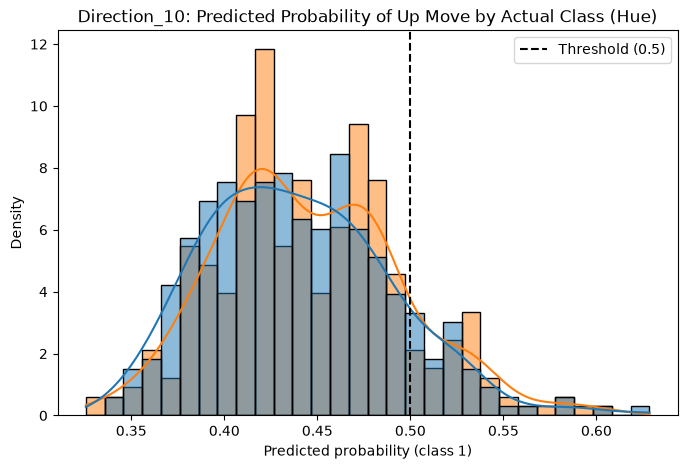

In [16]:
numeric_features = X_10.columns # All of the features are numeric but we will make the distinction for transparency

numeric_pipeline_10 = Pipeline([
    ("scaler", RobustScaler()) # There were outliers in violin/box plots from last NB
])

preprocessor_10 = ColumnTransformer([
    ("numeric", numeric_pipeline_10, numeric_features)
])

lr_10 = LogisticRegression(
    penalty='l1',
    C = 1.0,
    random_state=13,
    solver='liblinear', #default 'lbfgs' not L1-compatiable
    max_iter=1000,
    l1_ratio=1.0
)

pipeline_10 = Pipeline([
    ("preprocessor", preprocessor_10),
    ("classifier", lr_10)
])

print(pipeline_10.named_steps)

pipeline_10.fit(X_train_10, y_train_10)

y_pred_10 = pipeline_10.predict(X_test_10)
p_up_10 = pipeline_10.predict_proba(X_test_10)[:,1] #Probabilities

print(classification_report(y_test_10, y_pred_10))
print(f"ROC-AUC: {roc_auc_score(y_test_10, p_up_10):.4f}")

sns.histplot(x=p_up_10, hue=y_test_10.rename("Actual class"), bins=30, kde=True, stat="density", common_norm=False, ax=plt.subplots(figsize=(8, 5))[1])
plt.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
plt.title("Direction_10: Predicted Probability of Up Move by Actual Class (Hue)")
plt.xlabel("Predicted probability (class 1)")
plt.legend()
plt.show()


*Direction_20 (1 month)*

{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', RobustScaler())]),
                                 Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'EMA_7', 'IDR',
       'ATR_4', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist'],
      dtype='str', name='Price'))]), 'classifier': LogisticRegression(l1_ratio=1.0, max_iter=1000, penalty='l1', random_state=13,
                   solver='liblinear')}


c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.53      0.89      0.67       348
         1.0       0.45      0.10      0.16       304

    accuracy                           0.52       652
   macro avg       0.49      0.50      0.41       652
weighted avg       0.49      0.52      0.43       652

ROC-AUC: 0.5468


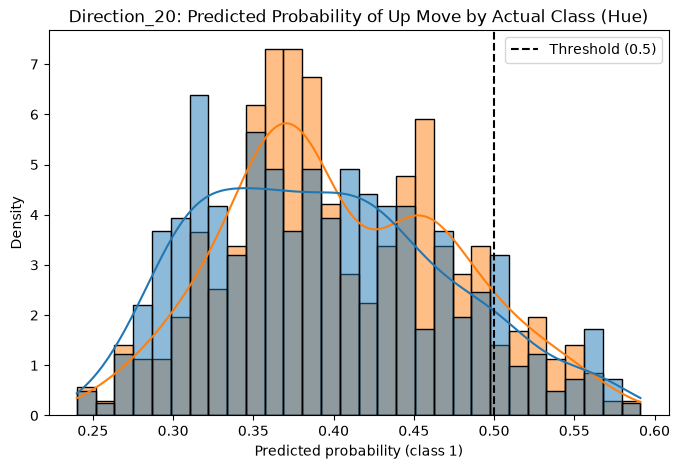

In [17]:
numeric_features = X_20.columns # All of the features are numeric but we will make the distinction for transparency

numeric_pipeline_20 = Pipeline([
    ("scaler", RobustScaler()) # There were outliers in violin/box plots from last NB
])

preprocessor_20 = ColumnTransformer([
    ("numeric", numeric_pipeline_20, numeric_features)
])

lr_20 = LogisticRegression(
    penalty='l1',
    C = 1.0,
    random_state=13,
    solver='liblinear', #default 'lbfgs' not L1-compatiable
    max_iter=1000,
    l1_ratio=1.0
)

pipeline_20 = Pipeline([
    ("preprocessor", preprocessor_20),
    ("classifier", lr_20)
])

print(pipeline_20.named_steps)

pipeline_20.fit(X_train_20, y_train_20)

y_pred_20 = pipeline_20.predict(X_test_20)
p_up_20 = pipeline_20.predict_proba(X_test_20)[:,1] #Probabilities

print(classification_report(y_test_20, y_pred_20))
print(f"ROC-AUC: {roc_auc_score(y_test_20, p_up_20):.4f}")

sns.histplot(x=p_up_20, hue=y_test_20.rename("Actual class"), bins=30, kde=True, stat="density", common_norm=False, ax=plt.subplots(figsize=(8, 5))[1])
plt.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
plt.title("Direction_20: Predicted Probability of Up Move by Actual Class (Hue)")
plt.xlabel("Predicted probability (class 1)")
plt.legend()
plt.show()


- Overall the best performance (by a small margin) is the 1-month direction model, based on F1-score.
- However the accuracy implies that it is a random process as to whether it gets the prediction correct for lots of the models, combined with the ROC-AUC score which sits at 0.5 (and slightly higher at 0.55 for direction_20 and 0.54 for direction_10).
- Let's take the 20 day model and tune it.
- FYI: Remember that LR is a linear model. Price data relationships are complex so it's no suprise that low performance is being observed here.

- Let's use RandomisedSearchCV and TimeSeriesSplit (essentially StratifiedKFold for temporal data) to help with this.
- Let's also optimise for ROC-AUC as opposed to accuracy or F1-score:
    - Threshold independence: It evaluates discrimination across different classification thresholds rather than assuming 0.5 is optimal.
    - Sensitivity to predictive signal: A classifier might achieve only 50% accuracy at a 0.5 threshold but have ROC-AUC of 0.60, indicating some ability to distinguish upward from downward movements.
    - Trading flexibility: You could subsequently select a decision threshold based on expected trading profitability, transaction costs and risk rather than accuracy alone.

*Direction_20 (2-week): Hypertuning*

In [18]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform

{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', RobustScaler())]),
                                 Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'EMA_7', 'IDR',
       'ATR_4', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist'],
      dtype='str', name='Price'))]), 'classifier': LogisticRegression(l1_ratio=1.0, max_iter=1000, penalty='l1', random_state=13,
                   solver='liblinear')}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'classifier__C': np.float64(0.00025679552018965105), 'classifier__class_weight': 'balanced', 'classifier__fit_intercept': False, 'classifier__penalty': 'l2', 'classifier__tol': 0.01}
Best CV ROC-AUC: 0.5403
              precision    recall  f1-score   support

         0.0       0.54      0.93      0.69       348
         1.0       0.56      0.10      0.17       304

    accuracy                           0.54       652
   macro avg  

c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=1.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


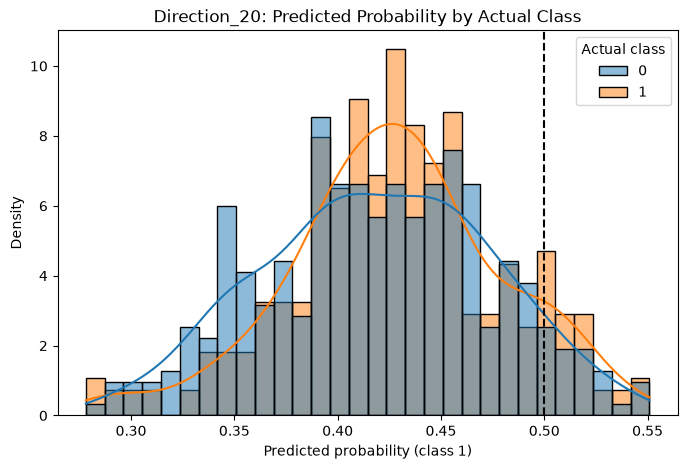

In [19]:
numeric_features = X_20.columns # All of the features are numeric but we will make the distinction for transparency

numeric_pipeline_20 = Pipeline([
    ("scaler", RobustScaler()) # There were outliers in violin/box plots from last NB
])

preprocessor_20 = ColumnTransformer([
    ("numeric", numeric_pipeline_20, numeric_features)
])

lr_20 = LogisticRegression(
    penalty='l1',
    C = 1.0,
    random_state=13,
    solver='liblinear', #default 'lbfgs' not L1-compatiable
    max_iter=1000,
    l1_ratio=1.0
)

pipeline_20 = Pipeline([
    ("preprocessor", preprocessor_20),
    ("classifier", lr_20)
])


print(pipeline_20.named_steps)

# Hyperparameter distributions
param_distributions_20 = {
    "classifier__C": loguniform(1e-4, 1e3),
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__fit_intercept": [True, False],
    "classifier__tol": [1e-4, 1e-3, 1e-2]
}

# Cross-validation
cv_20 = TimeSeriesSplit(
    n_splits=5,
    gap=20 # Excludes the first 20 observations before each validation fold as we are predicting 10 'periods' into the future
)

# Randomized hyperparameter search
random_search_20 = RandomizedSearchCV(
    estimator=pipeline_20,
    param_distributions=param_distributions_20,
    n_iter=100,
    scoring="roc_auc",
    cv=cv_20,
    n_jobs=-1,
    random_state=13,
    verbose=1,
    return_train_score=True,
    refit=True
)


random_search_20.fit(X_train_20, y_train_20)
pipeline_20 = random_search_20.best_estimator_

print("Best parameters:", random_search_20.best_params_)
print(f"Best CV ROC-AUC: {random_search_20.best_score_:.4f}")

y_pred_20 = pipeline_20.predict(X_test_20)
p_up_20 = pipeline_20.predict_proba(X_test_20)[:, 1]

print(classification_report(y_test_20, y_pred_20))
print(f"Test ROC-AUC: {roc_auc_score(y_test_20, p_up_20):.4f}")

# Probability distribution
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(x=p_up_20,hue=y_test_20.rename("Actual class"),bins=30,kde=True,stat="density",common_norm=False,ax=ax)

ax.axvline(0.5, color="k", linestyle="--")
ax.set_title("Direction_20: Predicted Probability by Actual Class")
ax.set_xlabel("Predicted probability (class 1)")
plt.show()

*Save this fitted pipeline:*

In [22]:
import joblib

from project_paths import DCN_MODEL_DIR

DCN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = DCN_MODEL_DIR / "dcn_20_lr_ht"

joblib.dump(pipeline_20, model_path)

['C:\\Users\\cochr\\Data Science Projects\\vlXsnPPgKKnWqEJB\\models\\direction\\dcn_20_lr_ht']

*The evaluation report has also been saved to the same directory*

When carrying out feature selection in the previous notebook, the MI and ETA-squared scores for the Direction_20 dataset suggested that the best features are:

- EMA_7          
- High           
- Close          
- SMA_7

Let's train a hypertuned and feature-selected model on the Direction_20 dataset:


{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', RobustScaler())]),
                                 Index(['EMA_7', 'High', 'Close', 'SMA_7'], dtype='str', name='Price'))]), 'classifier': LogisticRegression(l1_ratio=1.0, max_iter=1000, penalty='l1', random_state=13,
                   solver='liblinear')}
Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=1.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` p

Best parameters: {'classifier__C': np.float64(0.00025679552018965105), 'classifier__class_weight': 'balanced', 'classifier__fit_intercept': False, 'classifier__penalty': 'l2', 'classifier__tol': 0.01}
Best CV ROC-AUC: 0.6177
              precision    recall  f1-score   support

         0.0       0.53      1.00      0.70       348
         1.0       0.00      0.00      0.00       304

    accuracy                           0.53       652
   macro avg       0.27      0.50      0.35       652
weighted avg       0.28      0.53      0.37       652

Test ROC-AUC: 0.6241


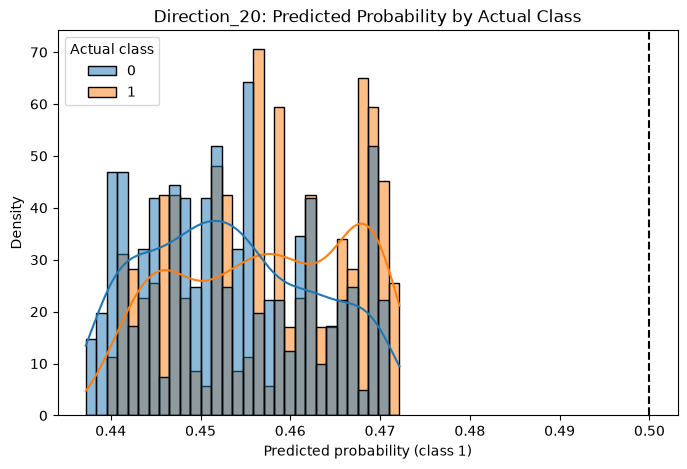

In [ ]:
X_train_20_fs = X_train_20[['EMA_7', 'High', 'Close', 'SMA_7']]
X_test_20_fs = X_test_20[['EMA_7', 'High', 'Close', 'SMA_7']]

numeric_features = X_train_20_fs.columns

numeric_pipeline_20 = Pipeline([
    ("scaler", RobustScaler()) # There were outliers in violin/box plots from last NB
])

preprocessor_20 = ColumnTransformer([
    ("numeric", numeric_pipeline_20, numeric_features)
])

lr_20 = LogisticRegression(
    penalty='l1',
    C = 1.0,
    random_state=13,
    solver='liblinear', #default 'lbfgs' not L1-compatiable
    max_iter=1000,
    l1_ratio=1.0
)

pipeline_20 = Pipeline([
    ("preprocessor", preprocessor_20),
    ("classifier", lr_20)
])


print(pipeline_20.named_steps)

# Hyperparameter distributions
param_distributions_20 = {
    "classifier__C": loguniform(1e-4, 1e3),
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__fit_intercept": [True, False],
    "classifier__tol": [1e-4, 1e-3, 1e-2]
}

# Cross-validation
cv_20 = TimeSeriesSplit(
    n_splits=5,
    gap=20 # Excludes the first 20 observations before each validation fold as we are predicting 10 'periods' into the future
)

# Randomized hyperparameter search
random_search_20 = RandomizedSearchCV(
    estimator=pipeline_20,
    param_distributions=param_distributions_20,
    n_iter=100,
    scoring="roc_auc",
    cv=cv_20,
    n_jobs=-1,
    random_state=13,
    verbose=1,
    return_train_score=True,
    refit=True
)


random_search_20.fit(X_train_20_fs, y_train_20)
pipeline_20 = random_search_20.best_estimator_

print("Best parameters:", random_search_20.best_params_)
print(f"Best CV ROC-AUC: {random_search_20.best_score_:.4f}")

y_pred_20 = pipeline_20.predict(X_test_20_fs)
p_up_20 = pipeline_20.predict_proba(X_test_20_fs)[:, 1]

print(classification_report(y_test_20, y_pred_20))
print(f"Test ROC-AUC: {roc_auc_score(y_test_20, p_up_20):.4f}")

# Probability distribution
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(x=p_up_20,hue=y_test_20.rename("Actual class"),bins=30,kde=True,stat="density",common_norm=False,ax=ax)

ax.axvline(0.5, color="k", linestyle="--")
ax.set_title("Direction_20: Predicted Probability by Actual Class")
ax.set_xlabel("Predicted probability (class 1)")
plt.show()

It's even worse. The discarded features apparently have useful information. Let's save the best model for now and move onto a better model type.